# NB-1 — Support vector machines: the gateway to kernels

**Roadmap:** `resources/topics_guide.md`, Part 1.

**Why this comes first.** Everything later in the roadmap — Gaussian process priors, additive kernels for exposure sources, BKMR, random Fourier features — is built on one object: a positive-definite kernel $k(x, x')$. The support vector machine is the cleanest place to meet it, because there the kernel appears for a purely mechanical reason. The optimisation problem only ever touches the data through inner products, and once you notice that, the kernel trick is almost forced on you.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Derive the **max-margin** classifier and explain why maximising the margin means minimising $\lVert w\rVert^2$.
- Move from the **primal** to the **dual** and say what each Lagrange multiplier means.
- Explain why the dual makes **support vectors** sparse, using complementary slackness from NB-0.
- Apply the **kernel trick**: replace an inner product with $k$ and get a nonlinear boundary from a linear solver.
- Say what function space an **RKHS** is, and why the margin is a norm in it.
- Write down the feature map of a **polynomial** kernel by hand, and explain why the RBF has none that is finite.
- Test whether an invented function is a **valid kernel**, and use the closure rules to build new ones safely.
- Explain the **soft margin** as hinge loss plus an $\ell_2$ penalty, and read $C$ as a bias–variance dial.

## What should already be familiar?

You should have worked through NB-0, in particular §0.1 (inner products and distances), §0.2 (positive-definite matrices) and §0.5 (Lagrangian duality and complementary slackness). Those three sections are used directly and repeatedly here.

You do not need to have met SVMs, RKHS theory, or Mercer's theorem before. Everything is NumPy plus one cross-check against scikit-learn at the very end. Allow about an hour.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 1.1 | What makes one separating line better than another? | A max-margin classifier solved by SMO |
| 1.2 | How do we get a curved boundary from a linear solver? | The same solver, one line changed |
| 1.3 | What does each kernel actually assume? | An explicit feature map, checked numerically |
| 1.4 | Which functions are legal kernels? | PSD tests and the closure rules |
| 1.5 | What happens when the classes overlap? | Soft margin, hinge loss, and the role of $C$ |

Sections 1.2 and 1.4 are the ones that matter most for everything that follows: 1.2 is the idea, 1.4 is the licence to invent your own kernels in NB-3.

Seven **Try it** boxes ask for an answer in your own words. The code below each one already runs — what you should be able to say about *why* it runs is the point.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
plt.rcParams.update({
    "figure.figsize": (5.0, 4.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

---
## 1.1 What makes one separating line better than another?

Data $\{(x_i, y_i)\}_{i=1}^n$ with $x_i \in \mathbb{R}^d$ and $y_i \in \{-1, +1\}$.
A hyperplane is $\{x : w^\top x + b = 0\}$. The signed distance from $x_i$ to it is
$(w^\top x_i + b)/\lVert w\rVert$, so the *geometric margin* of a correctly-classified
point is $y_i(w^\top x_i + b)/\lVert w \rVert$.

We want the hyperplane whose closest point is as far away as possible. The scale of
$(w,b)$ is arbitrary, so fix it by demanding the closest points satisfy
$y_i(w^\top x_i + b) = 1$ (the *canonical* form). The margin is then $2/\lVert w\rVert$
and maximising it means minimising $\lVert w \rVert^2$:

$$
\textbf{(Primal)}\qquad \min_{w,b}\ \tfrac12 \lVert w \rVert^2
\quad \text{s.t.}\quad y_i(w^\top x_i + b) \ge 1 \ \ \forall i .
$$

This is a convex QP in $d+1$ variables.

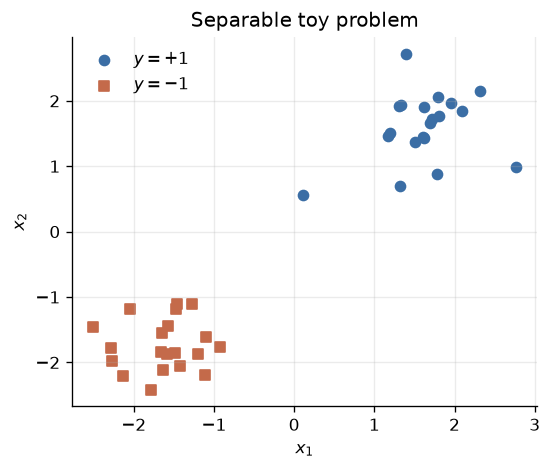

In [2]:
def make_linearly_separable(n=40, gap=1.6, seed=1):
    r = np.random.default_rng(seed)
    Xp = r.normal([ gap,  gap], 0.55, size=(n // 2, 2))
    Xn = r.normal([-gap, -gap], 0.55, size=(n // 2, 2))
    X = np.vstack([Xp, Xn])
    y = np.r_[np.ones(n // 2), -np.ones(n // 2)]
    return X, y

X, y = make_linearly_separable()

fig, ax = plt.subplots()
ax.scatter(*X[y > 0].T, c="#3b6ea5", label="$y=+1$")
ax.scatter(*X[y < 0].T, c="#c46a4a", marker="s", label="$y=-1$")
ax.legend(frameon=False)
ax.set_title("Separable toy problem")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
plt.show()

### Why rewrite the problem in terms of multipliers?

Attach a multiplier $\alpha_i \ge 0$ to each constraint. The Lagrangian is

$$
\mathcal{L}(w, b, \alpha) = \tfrac12 \lVert w \rVert^2
- \sum_i \alpha_i \big[ y_i (w^\top x_i + b) - 1 \big].
$$

Stationarity gives the two facts that make the whole subject work:

$$
\frac{\partial \mathcal{L}}{\partial w} = 0 \;\Rightarrow\; w = \sum_i \alpha_i y_i x_i,
\qquad
\frac{\partial \mathcal{L}}{\partial b} = 0 \;\Rightarrow\; \sum_i \alpha_i y_i = 0 .
$$

The first is the **representer property**: the optimal $w$ lives in the span of the data.
Substituting back eliminates $w$ and $b$ entirely:

$$
\textbf{(Dual)}\qquad
\max_{\alpha \ge 0}\ \sum_i \alpha_i - \tfrac12 \sum_{i,j} \alpha_i \alpha_j y_i y_j\, \underbrace{x_i^\top x_j}_{\text{inner product}}
\quad \text{s.t.}\quad \sum_i \alpha_i y_i = 0 .
$$

Two things to notice, because both are load-bearing later:

1. The data enters **only** as $x_i^\top x_j$. That is the opening for §1.2.
2. Complementary slackness ($\alpha_i[y_i f(x_i) - 1] = 0$) forces $\alpha_i = 0$ for every
   point strictly outside the margin. The surviving points are the **support vectors** —
   the sparsity that distinguishes an SVM from a GP, which keeps all $n$ points (Part 2).

### How do we actually solve it?

The equality constraint $\sum_i \alpha_i y_i = 0$ means we cannot move one $\alpha_i$ at a
time. **SMO** (sequential minimal optimisation) moves the smallest number that keeps the
constraint satisfiable — two — and solves that 2-variable subproblem in closed form. It
converges to the exact optimum, which matters here: only an exactly-solved dual gives the
true support-vector sparsity, and an unconverged $\alpha$ silently corrupts $b$.

Note what the routine's signature does *not* contain: `X`. It sees only $y$ and the Gram
matrix $K$. That is the whole setup for §1.2.

In [3]:
def svm_smo(K, y, C=1.0, tol=1e-6, max_passes=25, max_iter=500000, seed=0):
    """Sequential minimal optimisation for the SVM dual.

    Inputs are the Gram matrix K = k(X, X) and labels y only -- never X itself.
    Returns (alpha, b) at the KKT-satisfying optimum.
    """
    r = np.random.default_rng(seed)
    n = len(y)
    alpha = np.zeros(n)
    b = 0.0
    passes = it = 0

    while passes < max_passes and it < max_iter:
        changed = 0
        for i in range(n):
            f_i = (alpha * y) @ K[:, i] + b
            E_i = f_i - y[i]
            # KKT violation check
            if (y[i] * E_i < -tol and alpha[i] < C) or (y[i] * E_i > tol and alpha[i] > 0):
                j = r.integers(n - 1)
                j = j + (j >= i)                        # any j != i
                E_j = (alpha * y) @ K[:, j] + b - y[j]
                a_i_old, a_j_old = alpha[i], alpha[j]

                # box bounds on alpha_j that keep sum_i alpha_i y_i fixed
                if y[i] != y[j]:
                    L, H = max(0, a_j_old - a_i_old), min(C, C + a_j_old - a_i_old)
                else:
                    L, H = max(0, a_i_old + a_j_old - C), min(C, a_i_old + a_j_old)
                if H - L < 1e-12:
                    continue

                eta = 2 * K[i, j] - K[i, i] - K[j, j]    # second derivative; must be < 0
                if eta >= -1e-12:
                    continue

                alpha[j] = np.clip(a_j_old - y[j] * (E_i - E_j) / eta, L, H)
                if abs(alpha[j] - a_j_old) < 1e-10:
                    continue
                alpha[i] = a_i_old + y[i] * y[j] * (a_j_old - alpha[j])

                # b that restores the KKT conditions for whichever of i, j is unbound
                b1 = b - E_i - y[i] * (alpha[i] - a_i_old) * K[i, i] \
                             - y[j] * (alpha[j] - a_j_old) * K[i, j]
                b2 = b - E_j - y[i] * (alpha[i] - a_i_old) * K[i, j] \
                             - y[j] * (alpha[j] - a_j_old) * K[j, j]
                if 0 < alpha[i] < C:
                    b = b1
                elif 0 < alpha[j] < C:
                    b = b2
                else:
                    b = 0.5 * (b1 + b2)
                changed += 1
            it += 1
        passes = passes + 1 if changed == 0 else 0
    return alpha, b


def dual_objective(alpha, K, y):
    Q = (y[:, None] * y[None, :]) * K
    return alpha.sum() - 0.5 * alpha @ Q @ alpha

In [4]:
linear_kernel = lambda A, B: A @ B.T

K = linear_kernel(X, X)
alpha, b = svm_smo(K, y, C=1e6)          # C huge => effectively the hard-margin problem

sv = alpha > 1e-8
w = (alpha * y) @ X                      # w = sum_i alpha_i y_i x_i  (representer property)

print(f"support vectors : {sv.sum()} of {len(y)}")
print(f"w               : {np.round(w, 3)}")
print(f"b               : {b:+.3f}")
print(f"margin 2/||w||  : {2 / np.linalg.norm(w):.3f}")
print(f"dual objective  : {dual_objective(alpha, K, y):.4f}")
print(f"1/2 ||w||^2     : {0.5 * w @ w:.4f}   (equals the dual at optimum: strong duality)")
print(f"sum alpha_i y_i : {alpha @ y:+.2e}   (constraint, should be ~0)")
print(f"min_i y_i f(x_i): {(y * (X @ w + b)).min():.4f}   (canonical margin, should be ~1)")

support vectors : 2 of 40
w               : [0.588 0.711]
b               : +0.537
margin 2/||w||  : 2.169
dual objective  : 0.4253
1/2 ||w||^2     : 0.4253   (equals the dual at optimum: strong duality)
sum alpha_i y_i : +6.25e-17   (constraint, should be ~0)
min_i y_i f(x_i): 1.0000   (canonical margin, should be ~1)


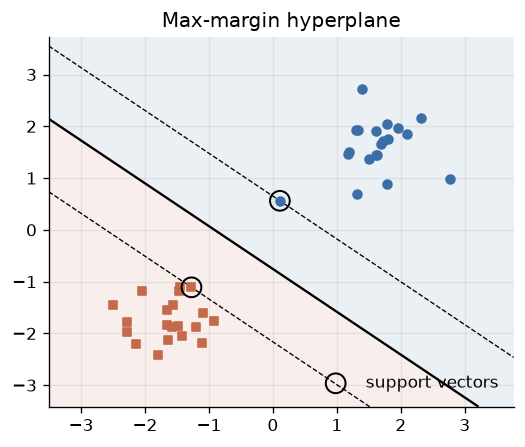

In [5]:
def plot_decision(ax, predict, X, y, title, levels=(-1, 0, 1), pad=1.0, grid=250):
    x1 = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, grid)
    x2 = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, grid)
    G1, G2 = np.meshgrid(x1, x2)
    Z = predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)

    ax.contourf(G1, G2, Z, levels=[-1e9, 0, 1e9], colors=["#c46a4a", "#3b6ea5"], alpha=0.10)
    ax.contour(G1, G2, Z, levels=levels, colors="k",
               linestyles=["--", "-", "--"], linewidths=[0.8, 1.4, 0.8])
    ax.scatter(*X[y > 0].T, c="#3b6ea5", s=28, zorder=3)
    ax.scatter(*X[y < 0].T, c="#c46a4a", s=28, marker="s", zorder=3)
    ax.set_title(title)
    return ax


fig, ax = plt.subplots()
plot_decision(ax, lambda G: G @ w + b, X, y, "Max-margin hyperplane")
ax.scatter(*X[sv].T, s=140, facecolors="none", edgecolors="k", linewidths=1.2,
           label="support vectors", zorder=4)
ax.legend(frameon=False, loc="lower right")
plt.show()

The circled points are the only ones with $\alpha_i > 0$. Delete any other point and the
solution is unchanged — the decision function is determined by a handful of observations
sitting exactly on the dashed margins.

### Try it 1. Why are so few points support vectors?

The fit used 2 of 40 points. Every other $\alpha_i$ came out exactly zero.

1. Using complementary slackness from NB-0 §0.5, explain in one sentence why points far from the boundary must have $\alpha_i = 0$.
2. Delete a non-support point and refit. Predict what happens *before* you run it, then try it.
3. Move one support vector slightly. Does the boundary move more or less than in (2)? What does that say about the stability of the fit?
4. A colleague says sparsity means the SVM "ignores most of the data". Is that a fair description? Answer in one or two sentences.

**Your answer**

*(write here)*

---
## 1.2 How do we get a curved boundary from a linear solver?

The dual sees the data only through $x_i^\top x_j$. So map the inputs through some
$\phi : \mathcal{X} \to \mathcal{H}$ into a (possibly infinite-dimensional) inner-product
space and run the *same* algorithm on $\langle \phi(x_i), \phi(x_j) \rangle_{\mathcal{H}}$.
We never need $\phi$ itself — only

$$
k(x, x') = \langle \phi(x), \phi(x') \rangle_{\mathcal{H}} .
$$

The decision function inherits the representer form,

$$
f(x) = \sum_i \alpha_i y_i\, k(x_i, x) + b ,
$$

a finite expansion even when $\mathcal{H}$ is infinite-dimensional. $\mathcal{H}$ is a
**reproducing kernel Hilbert space**: the space of functions spanned by $\{k(\cdot, x)\}$
with the reproducing property $\langle f, k(\cdot,x)\rangle_{\mathcal H} = f(x)$, and
$\lVert w \rVert^2_{\mathcal H} = \sum_{i,j}\alpha_i\alpha_j y_i y_j k(x_i,x_j)$ — so
"maximise the margin" becomes "find the smallest-RKHS-norm function that separates the
data". That norm is the regulariser, and in Part 2 the same $k$ reappears as a *covariance*
and the same penalty as a *log prior*.

In [6]:
def poly_kernel(A, B, degree=3, coef0=1.0, gamma=1.0):
    return (gamma * (A @ B.T) + coef0) ** degree

def rbf_kernel(A, B, gamma=1.0):
    d2 = np.sum(A**2, 1)[:, None] + np.sum(B**2, 1)[None, :] - 2 * A @ B.T
    return np.exp(-gamma * np.maximum(d2, 0.0))


class KernelSVM:
    """Soft-margin kernel SVM. The fit routine only ever sees K = k(X, X)."""

    def __init__(self, kernel=linear_kernel, C=1.0):
        self.kernel, self.C = kernel, C

    def fit(self, X, y):
        K = self.kernel(X, X)
        self.alpha, self.b_ = svm_smo(K, y, C=self.C)
        self.X_, self.y_ = X, y
        self.sv_ = self.alpha > 1e-8
        return self

    def decision_function(self, G):
        return (self.alpha * self.y_) @ self.kernel(self.X_, G) + self.b_

    def predict(self, G):
        return np.sign(self.decision_function(G))

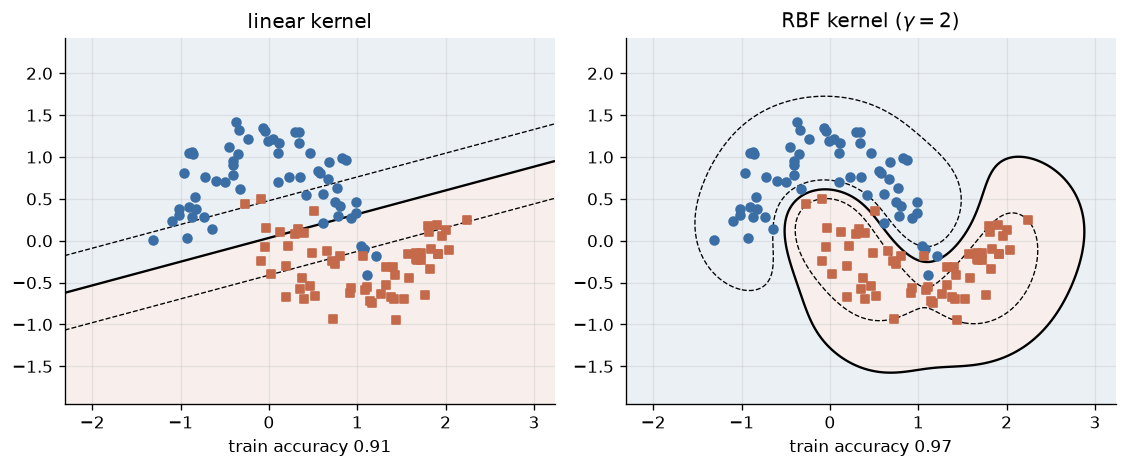

In [7]:
def make_moons_like(n=120, noise=0.22, seed=3):
    r = np.random.default_rng(seed)
    t = r.uniform(0, np.pi, n // 2)
    Xp = np.c_[np.cos(t), np.sin(t)] + r.normal(0, noise, (n // 2, 2))
    Xn = np.c_[1 - np.cos(t), 0.4 - np.sin(t)] + r.normal(0, noise, (n // 2, 2))
    X = np.vstack([Xp, Xn])
    y = np.r_[np.ones(n // 2), -np.ones(n // 2)]
    return X, y

Xm, ym = make_moons_like()

lin = KernelSVM(linear_kernel, C=1.0).fit(Xm, ym)
rbf = KernelSVM(lambda A, B: rbf_kernel(A, B, gamma=2.0), C=10.0).fit(Xm, ym)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))
for ax, m, name in zip(axes, [lin, rbf], ["linear kernel", "RBF kernel ($\\gamma=2$)"]):
    plot_decision(ax, m.decision_function, Xm, ym, name)
    acc = (m.predict(Xm) == ym).mean()
    ax.set_xlabel(f"train accuracy {acc:.2f}")
plt.tight_layout(); plt.show()

Same solver, same 20 lines of projected gradient ascent — one line of kernel changed. The
non-linearity is entirely in $k$, never in the optimiser.

### Try it 2. What exactly changed between the two panels?

The linear and RBF fits used the *same* `svm_smo` function, the same data, and the same 40 lines of solver code.

1. Name the single thing that differed.
2. `svm_smo` takes `K` and `y` and never sees `X`. Why is that the whole reason the kernel trick works?
3. The RBF fit reaches 0.97 training accuracy against the linear fit's 0.91. Why is that comparison, on its own, not evidence that the RBF is the better model?

**Your answer**

*(write here)*

---
## 1.3 What does each kernel actually assume?

| Kernel | $k(x,x')$ | Feature space $\phi$ |
|---|---|---|
| Linear | $x^\top x'$ | $\phi(x) = x$; $\dim = d$ |
| Polynomial | $(\gamma\, x^\top x' + c)^p$ | all monomials up to degree $p$; $\dim = \binom{d+p}{p}$ |
| RBF / Gaussian | $\exp(-\gamma \lVert x - x'\rVert^2)$ | infinite-dimensional |

The polynomial case is worth doing by hand once, because it is the one place the feature
map is small enough to write down. For $d=2$, $p=2$, $\gamma=1$, $c=1$:

$$
(x^\top x' + 1)^2 = 1 + 2x_1x'_1 + 2x_2x'_2 + x_1^2 x_1'^2 + x_2^2 x_2'^2 + 2x_1x_2x'_1x'_2,
$$

which is $\langle \phi(x), \phi(x')\rangle$ for
$\phi(x) = (1,\ \sqrt2 x_1,\ \sqrt2 x_2,\ x_1^2,\ x_2^2,\ \sqrt2 x_1x_2)$.
Six explicit features — and the kernel computes their inner product with one multiply and
one square. Note the appearance of the *interaction* term $x_1x_2$: this is the mechanism
by which kernel methods pick up exposure–exposure interactions without them being coded by
hand, and it is exactly what BKMR (6.3) and ANOVA kernels (3.4) exploit.

In [8]:
def phi_poly2(X):
    x1, x2 = X[:, 0], X[:, 1]
    s2 = np.sqrt(2.0)
    return np.c_[np.ones(len(X)), s2 * x1, s2 * x2, x1**2, x2**2, s2 * x1 * x2]

A, B = rng.normal(size=(4, 2)), rng.normal(size=(3, 2))
explicit = phi_poly2(A) @ phi_poly2(B).T
implicit = poly_kernel(A, B, degree=2, coef0=1.0, gamma=1.0)

print("max |<phi(x), phi(x')> - k(x, x')| =", np.abs(explicit - implicit).max())

max |<phi(x), phi(x')> - k(x, x')| = 9.43689570931383e-16


In [9]:
from math import factorial

# The RBF has no finite feature map, but its Taylor expansion shows why:
#   exp(-g||x-x'||^2) = exp(-g||x||^2) exp(-g||x'||^2) * sum_m (2g)^m (x.x')^m / m!
# an infinite weighted sum of polynomial kernels of every degree.
gamma = 1.0
Aa, Bb = rng.normal(size=(3, 2)), rng.normal(size=(3, 2))
exact = rbf_kernel(Aa, Bb, gamma)

for M in [2, 4, 8, 16]:
    dot = Aa @ Bb.T
    series = sum((2 * gamma) ** m * dot**m / factorial(m) for m in range(M + 1))
    approx = np.exp(-gamma * np.sum(Aa**2, 1))[:, None] * np.exp(-gamma * np.sum(Bb**2, 1))[None, :] * series
    print(f"degrees <= {M:2d}:  max abs error {np.abs(approx - exact).max():.2e}")

degrees <=  2:  max abs error 3.48e-01
degrees <=  4:  max abs error 9.66e-02
degrees <=  8:  max abs error 1.43e-03
degrees <= 16:  max abs error 4.05e-09


### Try it 3. Where do interactions come from?

The degree-2 polynomial map was written out in full: $\phi(x) = (1, \sqrt2 x_1, \sqrt2 x_2, x_1^2, x_2^2, \sqrt2 x_1x_2)$.

1. Point to the term that represents an **interaction** between the two inputs.
2. You never asked for that term. What does that mean for a mixtures analysis where two pollutants might act synergistically?
3. The RBF was shown to be an infinite weighted sum of polynomial kernels of every degree. What does that imply about which interaction orders an RBF includes?
4. Given (3), why might you still *prefer* an explicit degree-2 kernel in an epidemiological paper?

**Your answer**

*(write here)*

### Why is the lengthscale the most consequential number?

$\gamma = 1/(2\ell^2)$ controls how far a training point's influence reaches. It is the
single most consequential knob in every kernel method downstream — as ARD lengthscales it
*becomes* variable selection in 2.3 and 5.1, because sending $\ell_j \to \infty$ switches
off exposure $j$.

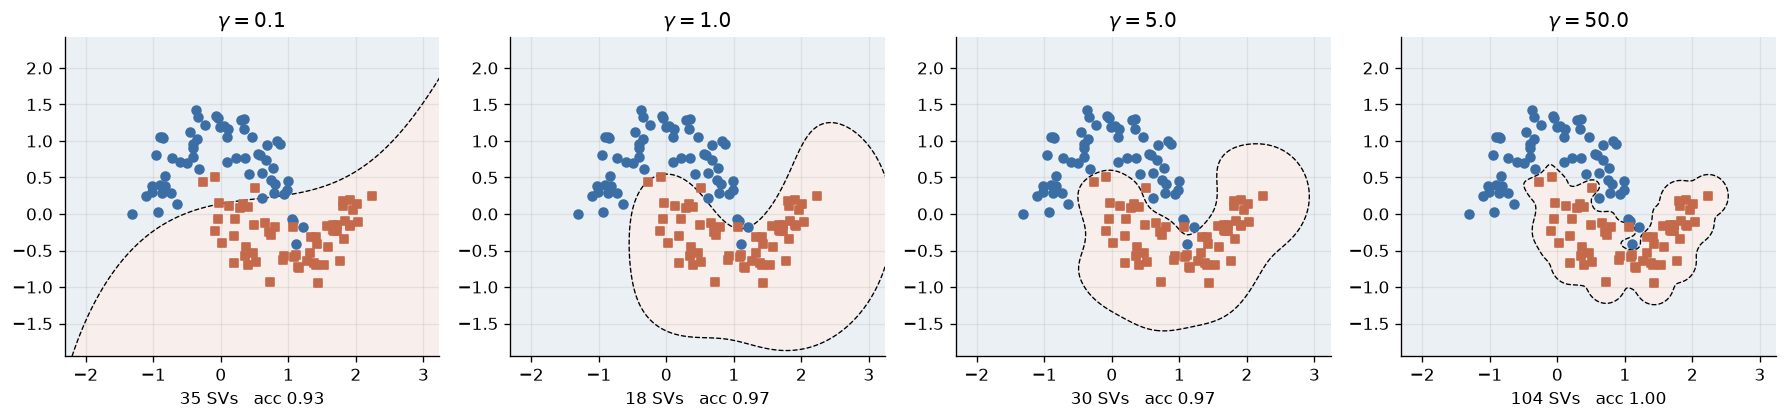

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, g in zip(axes, [0.1, 1.0, 5.0, 50.0]):
    m = KernelSVM(lambda A, B, g=g: rbf_kernel(A, B, g), C=10.0).fit(Xm, ym)
    plot_decision(ax, m.decision_function, Xm, ym, f"$\\gamma={g}$", levels=(0,))
    ax.set_xlabel(f"{m.sv_.sum()} SVs   acc {(m.predict(Xm) == ym).mean():.2f}")
plt.tight_layout(); plt.show()

Left to right: too smooth to see the moons, about right, tightening, and finally each point
defending its own island — the kernel-method face of overfitting. Nothing about the training
accuracy warns you; only held-out data or the marginal likelihood (2.4) does.

### Try it 4. Which of those four panels would you trust?

The $\gamma$ sweep ran from 0.1 to 50, and training accuracy never fell.

1. Describe, in words, what the model is claiming about the world at $\gamma = 50$.
2. Training accuracy did not warn you. Name two things that would have.
3. $\gamma = 1/(2\ell^2)$. Restate the overfitting story in terms of the lengthscale $\ell$ rather than $\gamma$ — which direction is dangerous?
4. In NB-2 this same lengthscale becomes *one per input*, and fitting them becomes variable selection. Sketch how you think that would work.

**Your answer**

*(write here)*

---
## 1.4 Which functions are legal kernels?

Not every symmetric $k$ corresponds to an inner product. The requirement is **positive
semi-definiteness**: for every finite set $\{x_i\}$ and every $c \in \mathbb{R}^n$,

$$
\sum_{i,j} c_i c_j\, k(x_i, x_j) \ge 0
\qquad\Longleftrightarrow\qquad
K \succeq 0 \ \text{ for every Gram matrix } K .
$$

Mercer's theorem says such a $k$ admits an expansion
$k(x,x') = \sum_m \lambda_m \psi_m(x)\psi_m(x')$ with $\lambda_m \ge 0$, i.e. a feature map
$\phi(x) = (\sqrt{\lambda_m}\,\psi_m(x))_m$ exists. If $K$ has a negative eigenvalue the
dual is non-concave and the "distance" $\lVert\phi(x)-\phi(x')\rVert^2$ can be negative —
the geometry is broken, not merely inconvenient.

**Closure rules** (the practical payoff, and the basis of Part 3's kernel construction):
if $k_1, k_2$ are valid then so are $k_1 + k_2$, $k_1 k_2$, $c\,k_1$ for $c>0$,
$f(x)k_1(x,x')f(x')$, and $k_1(\psi(x),\psi(x'))$ for any map $\psi$. Sums give **additive**
kernels (3.2 — one term per exposure source); products give **tensor-product / interaction**
kernels (3.4).

In [11]:
def psd_report(name, K, tol=1e-9):
    K = 0.5 * (K + K.T)
    ev = np.linalg.eigvalsh(K)
    ok = ev.min() > -tol * max(1.0, abs(ev).max())
    print(f"{name:<34} lambda_min = {ev.min():+.3e}   {'PSD  ok' if ok else 'NOT PSD'}")
    return ev

Z = rng.normal(size=(60, 2))

_ = psd_report("linear", linear_kernel(Z, Z))
_ = psd_report("polynomial p=3", poly_kernel(Z, Z, 3))
_ = psd_report("RBF gamma=1", rbf_kernel(Z, Z, 1.0))
_ = psd_report("RBF + poly   (sum rule)", rbf_kernel(Z, Z, 1.0) + poly_kernel(Z, Z, 2))
_ = psd_report("RBF * poly   (product rule)", rbf_kernel(Z, Z, 1.0) * poly_kernel(Z, Z, 2))
print()
# Popular but NOT a kernel in general: sigmoid / "neural" kernel tanh(a x.x' + c)
_ = psd_report("sigmoid tanh(x.x' + 1)", np.tanh(Z @ Z.T + 1.0))
# Nor is a plain distance
_ = psd_report("negative Euclidean distance", -np.sqrt(np.maximum(
    np.sum(Z**2, 1)[:, None] + np.sum(Z**2, 1)[None, :] - 2 * Z @ Z.T, 0)))

linear                             lambda_min = -1.459e-14   PSD  ok
polynomial p=3                     lambda_min = -3.344e-13   PSD  ok
RBF gamma=1                        lambda_min = +1.082e-08   PSD  ok
RBF + poly   (sum rule)            lambda_min = +1.119e-08   PSD  ok
RBF * poly   (product rule)        lambda_min = +3.164e-07   PSD  ok

sigmoid tanh(x.x' + 1)             lambda_min = -7.187e+00   NOT PSD
negative Euclidean distance        lambda_min = -1.077e+02   NOT PSD


The sigmoid "kernel" is a standard trap: it is offered by most SVM libraries and is
indefinite for most hyperparameter choices. Solvers usually still return *something*, which
is why checking $\lambda_{\min}$ on a subsample is a cheap habit whenever you invent a
kernel — and you will invent kernels in Part 3.

### Try it 5. How would you check a kernel you invented?

The sigmoid "kernel" came out with $\lambda_{\min} = -7.19$, and most libraries will happily offer it to you anyway.

1. What goes wrong, geometrically, when a Gram matrix has a negative eigenvalue? Refer to the distance identity from NB-0 §0.1.
2. Write down the three closure rules from this section, from memory if you can.
3. You want a kernel that says "similar in air pollution **and** similar in diet". Sum or product? What about "similar in either one"?
4. Design one kernel of your own for an exposure you care about, and say which closure rule guarantees it is valid.

**Your answer**

*(write here)*

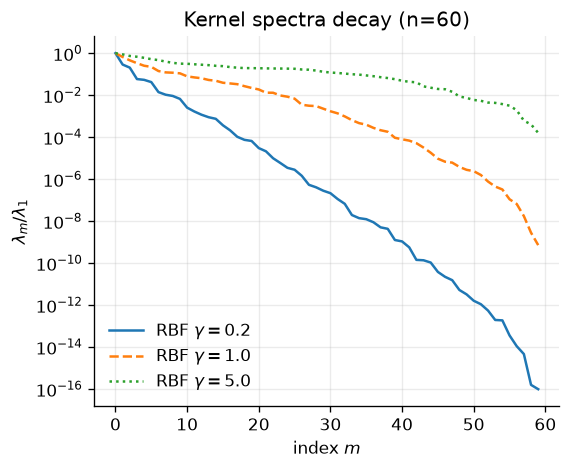

In [12]:
# Mercer eigenvalues: how quickly the RBF's spectrum decays sets its effective dimension,
# and is exactly what Nystrom / random Fourier features (7.1) exploit.
fig, ax = plt.subplots()
for g, style in [(0.2, "-"), (1.0, "--"), (5.0, ":")]:
    ev = np.sort(np.linalg.eigvalsh(rbf_kernel(Z, Z, g)))[::-1]
    ax.semilogy(np.maximum(ev, 1e-16) / ev[0], style, label=f"RBF $\\gamma={g}$")
ax.set_xlabel("index $m$"); ax.set_ylabel("$\\lambda_m / \\lambda_1$")
ax.set_title("Kernel spectra decay (n=60)")
ax.legend(frameon=False); plt.show()

Smooth kernels (small $\gamma$) have spectra that collapse after a few dozen components:
the Gram matrix is numerically low-rank, so a rank-$m$ approximation is nearly free. Sharp
kernels stay near full rank and cost the full $O(n^3)$. That trade-off is the entire subject
of 7.1.

---
## 1.5 What happens when the classes overlap?

Real data are not separable. Introduce slack $\xi_i \ge 0$ and pay for it:

$$
\min_{w,b,\xi}\ \tfrac12\lVert w\rVert^2 + C\sum_i \xi_i
\quad\text{s.t.}\quad y_i(w^\top x_i + b) \ge 1 - \xi_i,\ \ \xi_i \ge 0 .
$$

At the optimum $\xi_i = \max(0,\,1 - y_i f(x_i))$, so this is *exactly* unconstrained
**hinge loss plus an $\ell_2$ penalty**:

$$
\min_{w,b}\ \underbrace{\sum_i \max\!\big(0,\ 1 - y_i f(x_i)\big)}_{\text{hinge loss}}
\;+\; \underbrace{\tfrac{1}{2C}\lVert w\rVert^2}_{\text{RKHS regulariser}} .
$$

In the dual, all of this amounts to one change: $\alpha_i \ge 0$ becomes
$0 \le \alpha_i \le C$. The multipliers can no longer grow without bound, so no single point
can dominate the fit. Small $C$ = strong regularisation = wide, soft margin.

The loss/penalty split is the template for the rest of the guide: swap hinge for a Gaussian
log-likelihood and the $\ell_2$ penalty for a GP prior and you have Part 2; swap the penalty
for a horseshoe and you have 4.5.

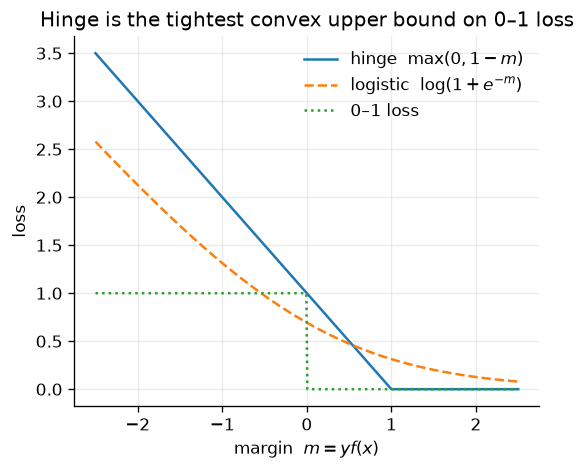

In [13]:
fig, ax = plt.subplots()
m_ = np.linspace(-2.5, 2.5, 400)
ax.plot(m_, np.maximum(0, 1 - m_), label="hinge  $\\max(0, 1-m)$")
ax.plot(m_, np.log1p(np.exp(-m_)), "--", label="logistic  $\\log(1+e^{-m})$")
ax.plot(m_, (m_ < 0).astype(float), ":", label="0–1 loss")
ax.set_xlabel("margin  $m = y f(x)$"); ax.set_ylabel("loss")
ax.set_title("Hinge is the tightest convex upper bound on 0–1 loss")
ax.legend(frameon=False); plt.show()

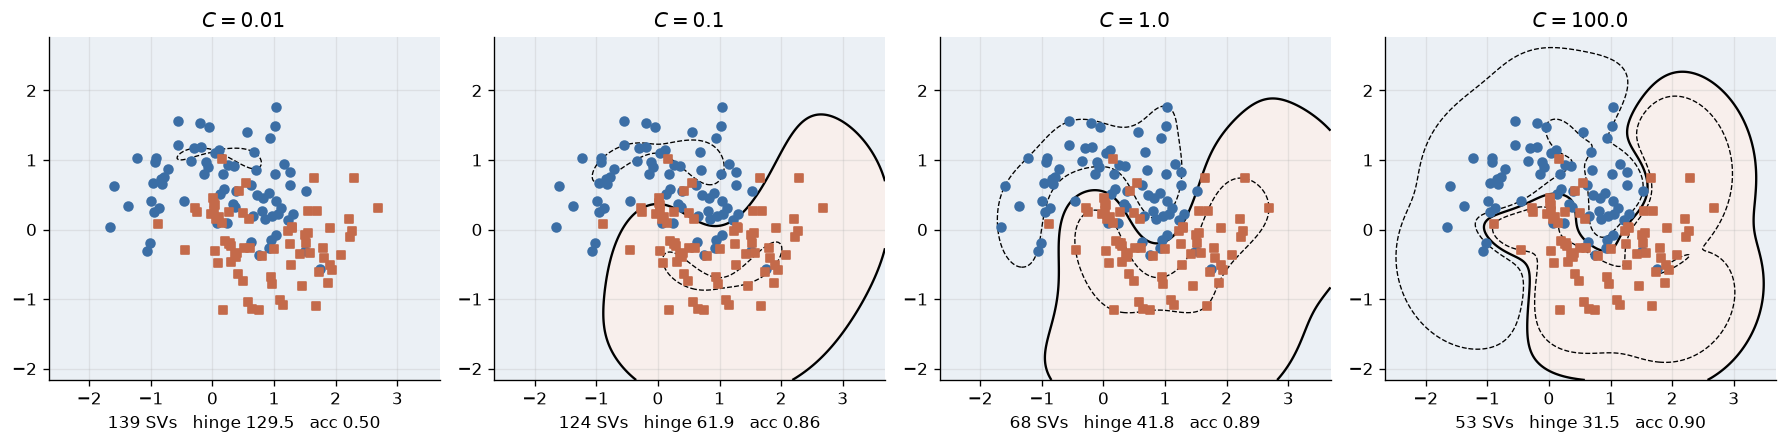

In [14]:
Xn_, yn_ = make_moons_like(n=140, noise=0.42, seed=11)   # overlapping classes

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, Cv in zip(axes, [0.01, 0.1, 1.0, 100.0]):
    m = KernelSVM(lambda A, B: rbf_kernel(A, B, 1.5), C=Cv).fit(Xn_, yn_)
    plot_decision(ax, m.decision_function, Xn_, yn_, f"$C={Cv}$")
    margin = yn_ * m.decision_function(Xn_)
    hinge = np.maximum(0, 1 - margin).sum()
    ax.set_xlabel(f"{m.sv_.sum()} SVs   hinge {hinge:.1f}   acc {(np.sign(margin) > 0).mean():.2f}")
plt.tight_layout(); plt.show()

As $C$ grows the margin narrows, the support-vector count falls, hinge loss drops and the
boundary starts chasing individual noisy points. The bias–variance dial is $C$; the shape
dial is $\gamma$; they interact, which is why they are tuned jointly.

### Try it 6. What is $C$ really trading off?

As $C$ went from 0.01 to 100 the support-vector count fell from 139 to 53 and the hinge loss fell from 129.5 to 31.5.

1. Explain in one sentence why *fewer* support vectors indicates *less* regularisation.
2. The soft margin is hinge loss $+\frac{1}{2C}\lVert w\rVert^2$. Which term dominates as $C \to 0$, and what boundary does that give?
3. $C$ and $\gamma$ interact. Give a concrete example of two settings that produce a similar-looking boundary for different reasons.
4. In NB-2 this decomposition becomes log-likelihood + log-prior. Which piece of the soft-margin objective plays the role of the prior?

**Your answer**

*(write here)*

In [15]:
# Cross-check the from-scratch solver against a real QP solver.
from sklearn.svm import SVC

ref = SVC(kernel="rbf", gamma=1.5, C=1.0).fit(Xn_, yn_)
ours = KernelSVM(lambda A, B: rbf_kernel(A, B, 1.5), C=1.0).fit(Xn_, yn_)

f_ref, f_ours = ref.decision_function(Xn_), ours.decision_function(Xn_)
print(f"agreement on labels : {(np.sign(f_ref) == np.sign(f_ours)).mean():.3f}")
print(f"corr(f_ref, f_ours) : {np.corrcoef(f_ref, f_ours)[0, 1]:.4f}")
print(f"support vectors     : sklearn {len(ref.support_)}   ours {ours.sv_.sum()}")

agreement on labels : 1.000
corr(f_ref, f_ours) : 1.0000
support vectors     : sklearn 68   ours 68


### Try it 7. What did the scikit-learn comparison prove?

The from-scratch solver matched `SVC` on every label, with correlation 1.0000 and the identical 68 support vectors.

1. State precisely what this does and does not establish about the code.
2. An earlier draft of this notebook used a different solver that reported correlation 1.0000 but disagreed with `SVC` on 8% of labels. How is that possible? What quantity must have been wrong?
3. Given (2), what would be a better single check than correlation?

**Your answer**

*(write here)*

## What can we conclude?

The dual objective touches the data only through inner products. That one observation is the whole of Part 1, and everything else in the roadmap follows from taking it seriously.

| What we established | Where it is used next |
|---|---|
| Data enters only as $x_i^\top x_j$ | NB-2 replaces similarity with **covariance** and gets a posterior instead of a point estimate |
| PSD closure rules (§1.4) | NB-3's construction kit: sums for exposure sources, products for interactions |
| One lengthscale controls smoothness (§1.3) | NB-2 §2.3 gives each input its own, which becomes variable selection in NB-5 |
| Loss + RKHS penalty (§1.5) | the same object as log-likelihood + log-prior — how the deterministic story becomes Bayesian |
| Kernel spectra decay (§1.4) | the assumption behind Nyström and random Fourier features in NB-7 §7.1 |

The one sentence to carry forward: **choosing a kernel is choosing what "similar" means**, and in NB-2 that becomes choosing a prior over functions.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–7**.
- Change $\gamma$ or $C$ somewhere and record what happened and whether it surprised you.
- State, without looking back, why the SVM dual has anything to do with kernels.

**Going further (optional)**

1. Solve the primal QP directly with `scipy.optimize` and confirm $w = \sum_i \alpha_i y_i x_i$ recovers the same hyperplane. Check strong duality by comparing the two objective values.
2. Implement an **ARD-RBF** kernel with one lengthscale per input on a problem where only 2 of 10 inputs matter. Tune by cross-validation and see which lengthscales blow up. This is NB-2 §2.3 in miniature.
3. Build an additive kernel $k = k_{\text{air}} + k_{\text{diet}}$ over disjoint column blocks, confirm it is PSD, then check whether the fit is genuinely additive.
4. Show that centring a kernel matrix, $\tilde K = HKH$, preserves PSD. That is the first step of kernel PCA in NB-5 §5.4.

*NB-2 keeps the kernel and throws away the classifier: the same $k$ becomes a covariance function, and the answer becomes a distribution rather than a line.*